In [151]:
import pandas as pd

In [152]:
dados = pd.read_csv(r'Dados\Preços_de_casas.csv')


In [153]:
dados.info()


<class 'pandas.DataFrame'>
RangeIndex: 1438 entries, 0 to 1437
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Id                              1438 non-null   int64  
 1   area_primeiro_andar             1438 non-null   float64
 2   existe_segundo_andar            1438 non-null   int64  
 3   area_segundo_andar              1438 non-null   float64
 4   quantidade_banheiros            1438 non-null   int64  
 5   capacidade_carros_garagem       1438 non-null   int64  
 6   qualidade_da_cozinha_Excelente  1438 non-null   int64  
 7   preco_de_venda                  1438 non-null   float64
dtypes: float64(3), int64(5)
memory usage: 90.0 KB


In [154]:
dados = dados.drop(columns=["Id"])

In [155]:
corr = dados.corr()

In [156]:
corr['preco_de_venda']

area_primeiro_andar               0.616557
existe_segundo_andar              0.138541
area_segundo_andar                0.305311
quantidade_banheiros              0.563132
capacidade_carros_garagem         0.640214
qualidade_da_cozinha_Excelente    0.496223
preco_de_venda                    1.000000
Name: preco_de_venda, dtype: float64

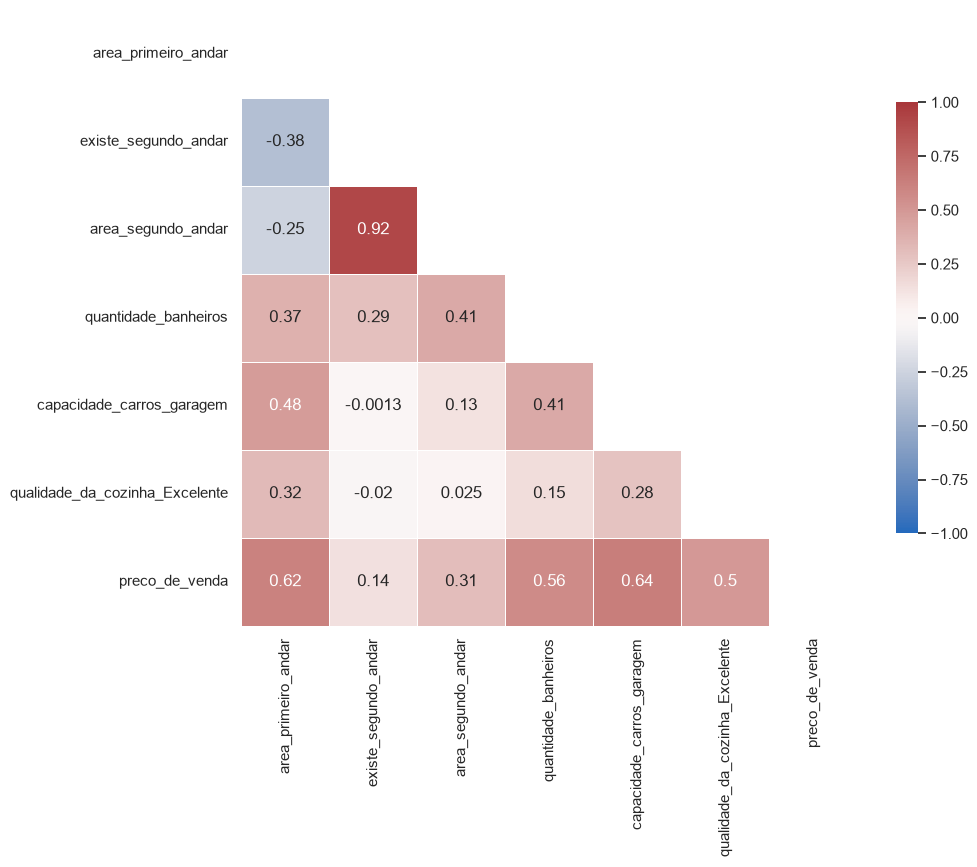

In [157]:
# Importa as bibliotecas necessárias para análise e visualização de dados
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configura o estilo dos gráficos do Seaborn para um visual mais limpo
sns.set_theme(style="white")

# 1. Calcula a matriz de correlação de todas as variáveis do DataFrame 'dados'
corr = dados.corr()

# 2. Cria uma máscara para o triângulo superior da matriz
# Como a matriz é simétrica, a parte de cima e a de baixo são iguais. 
# Usamos a máscara para esconder a metade superior e evitar redundância.
mask = np.triu(np.ones_like(corr, dtype=bool))

# 3. Configura o tamanho da figura (largura x altura em polegadas)
f, ax = plt.subplots(figsize=(10, 8))

# 4. Define a paleta de cores divergente (azul para negativo, vermelho para positivo, branco para neutro)
# O mapa de cores 'coolwarm' ou 'vlag' replica exatamente o tom do seu exercício
cmap = sns.color_palette("vlag", as_cmap=True)

# 5. Desenha o mapa de calor (heatmap) com os parâmetros específicos da imagem:
sns.heatmap(
    corr,                      # Os dados da nossa matriz de correlação
    mask=mask,                 # Aplica a máscara para ocultar o triângulo superior
    cmap=cmap,                 # Aplica a paleta de cores definida acima
    vmax=1.0,                  # Valor máximo da escala de cor (Correlação Perfeita Positiva)
    vmin=-1.0,                 # Valor mínimo da escala de cor (Correlação Perfeita Negativa)
    center=0,                  # Define o ponto neutro (zero) no meio da escala
    annot=True,                # Mostra os valores numéricos dentro dos quadrados
    fmt=".2g",                 # Formata os números para mostrar de forma limpa (ex: 0.32, -0.0026)
    square=True,               # Força cada célula a ser um quadrado perfeito
    linewidths=.5,             # Cria as linhas brancas divisórias entre os quadrados
    cbar_kws={"shrink": .7}    # Encolhe um pouco a barra lateral de cores para ajustar ao layout
)

# 6. Exibe o gráfico finalizado na tela
plt.show()


In [158]:
# Importando as visualizações
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import plotly.io as pio
pio.renderers.default = "png"


Text(0, 0.5, 'Preço de venda')

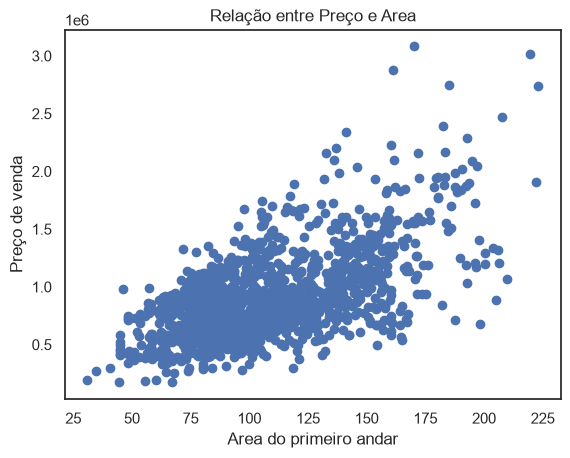

In [159]:
# Aparentemente, quanto maior a área do primeiro andar, maior o preço da casa.
# E se quisermos traçar uma linha que melhor representa esse comportamento?
plt.scatter(dados['area_primeiro_andar'], dados['preco_de_venda'])
plt.title("Relação entre Preço e Area")
plt.xlabel("Area do primeiro andar")
plt.ylabel("Preço de venda")

Text(0, 0.5, 'Preço de venda')

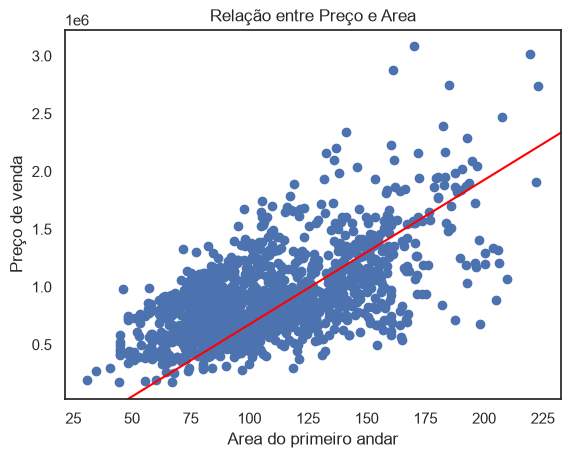

In [160]:
# Aparentemente, quanto maior a área do primeiro andar, maior o preço da casa.
# E se quisermos traçar uma linha que melhor representa esse comportamento?
plt.scatter(dados['area_primeiro_andar'], dados['preco_de_venda'])
plt.axline(xy1 = (66, 250000),xy2 = (190, 1800000), color = "red" )
plt.title("Relação entre Preço e Area")
plt.xlabel("Area do primeiro andar")
plt.ylabel("Preço de venda")

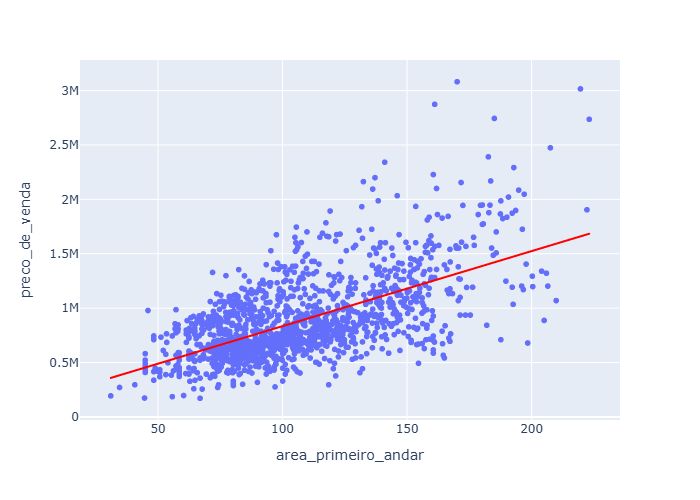

In [161]:
# Qual a reta que melhor se adequa a relação?

# Cria o gráfico de dispersão com a linha de regressão linear customizada na cor vermelha
# - dados: Nosso conjunto de dados (DataFrame)
# - x: Variável preditora no eixo X (Área do primeiro andar)
# - y: Variável resposta no eixo Y (Preço de venda do imóvel)
# - trendline='ols': Método dos Mínimos Quadrados para calcular a reta de tendência
# - trendline_color_override='red': Altera especificamente a cor da linha de tendência para vermelho
px.scatter(
    dados, 
    x='area_primeiro_andar', 
    y='preco_de_venda', 
    trendline='ols',
    trendline_color_override='red'
)


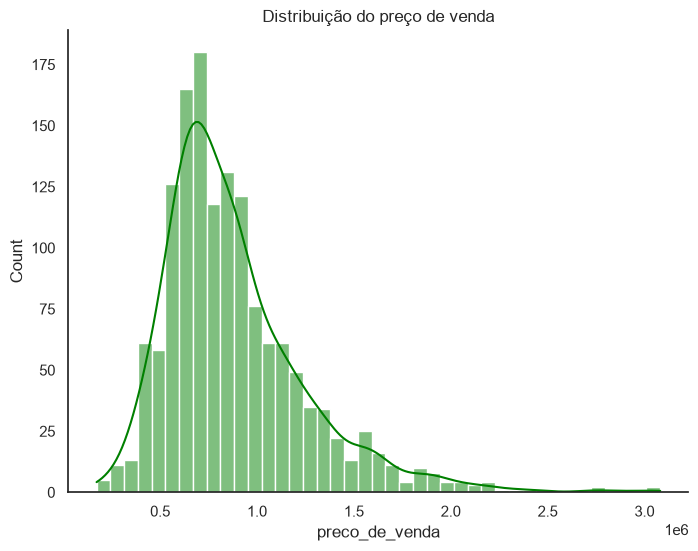

In [162]:
# Distribuição do preço de venda

# Configura o tamanho da janela do gráfico (largura x altura em polegadas)
plt.figure(figsize=(8, 6))

# Cria o histograma com linha de densidade usando o Seaborn
# - dados: Nosso conjunto de dados (DataFrame)
# - x: A coluna numérica que queremos analisar (Preço de venda)
# - kde=True: Adiciona a linha suave de estimativa de densidade de kernel por cima das barras
# - color='green': Define a cor verde idêntica à do exercício para as barras e para a linha
sns.histplot(
    data=dados, 
    x='preco_de_venda', 
    kde=True, 
    color='green'
)

# Adiciona o título centralizado no topo do gráfico
plt.title('Distribuição do preço de venda')

# Remove as bordas superior (top) e direita (right) do gráfico para um visual mais limpo e minimalista
sns.despine()

# Exibe o gráfico finalizado na tela
plt.show()


In [163]:
# Importa a função necessária para dividir os dados em conjuntos de treino e teste

# A função 'train_test_split' separa nossa base de dados de forma aleatória, 
# permitindo que o modelo treine com uma parte e seja testado com dados inéditos.
from sklearn.model_selection import train_test_split


In [164]:
#Definindo y e X
y = dados['preco_de_venda']
X = dados.drop(columns = 'preco_de_venda')

In [165]:
# Aplicando a divisão (split) dos dados em treino e teste para as variáveis X e y

# A função 'train_test_split' separa nossos dados aleatoriamente em quatro partes:
# - X: Variáveis explicativas/características do imóvel (ex: áreas, quartos, etc.)
# - y: Variável dependente/alvo que queremos prever (preço de venda)
# - test_size = 0.3: Reserva exatamente 30% da nossa base para testes e usa os 70% restantes para treinar o modelo
# - random_state = 230: Garante que a divisão aleatória seja idêntica sempre que o código for executado (reprodutibilidade)
x_train, x_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.3, 
    random_state=230
)


In [166]:
#Dados de treino para usar a fórmula
df_train = pd.DataFrame(data= x_train) 
df_train['preco_de_venda'] = y_train

In [167]:
# Importa o módulo OLS (Ordinary Least Squares - Mínimos Quadrados Ordinários)
from statsmodels.formula.api import ols


In [168]:
# ajustando o primeiro modelo
modelo_0 = ols('preco_de_venda ~ area_primeiro_andar', data = df_train).fit()

Analisando os coeficientes 

In [169]:
# visualizando os parametros
modelo_0.params

Intercept              152909.288334
area_primeiro_andar      6793.641641
dtype: float64

In [170]:
# o resumo do nosso modelo
print(modelo_0.summary())

                            OLS Regression Results                            
Dep. Variable:         preco_de_venda   R-squared:                       0.377
Model:                            OLS   Adj. R-squared:                  0.377
Method:                 Least Squares   F-statistic:                     608.3
Date:                Fri, 12 Jun 2026   Prob (F-statistic):          2.22e-105
Time:                        22:57:32   Log-Likelihood:                -14082.
No. Observations:                1006   AIC:                         2.817e+04
Df Residuals:                    1004   BIC:                         2.818e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept            1.529e+05   3

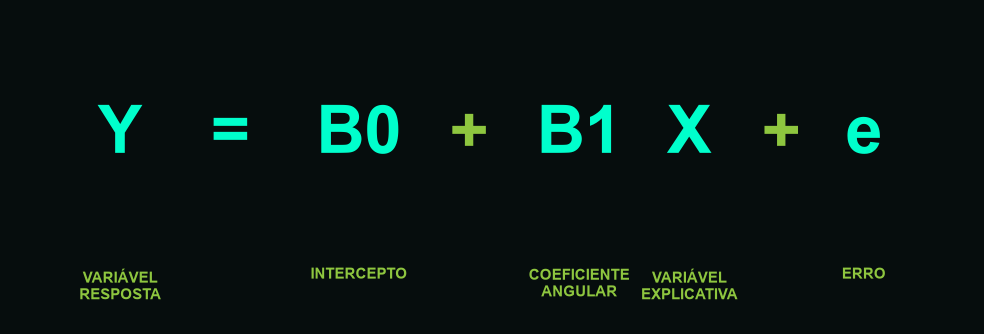

In [171]:
# Infográfico explicativo dos componentes da Equação de Regressão Linear com Erro

# Ativa o estilo de fundo escuro para corresponder ao slide
plt.style.use('dark_background')

# Cria a estrutura do painel com a cor de fundo customizada do slide
fig, ax = plt.subplots(figsize=(10, 3.5), facecolor='#060d0d')
ax.set_facecolor('#060d0d')

# Remove as bordas e marcações de eixos para focar apenas nos blocos de texto
ax.axis('off')

# 1. Desenha os caracteres da equação matemática principal (Cor Ciano e Verde)
ax.text(0.12, 0.6, 'Y', color='#00ffcc', fontsize=48, fontweight='bold', ha='center', va='center')
ax.text(0.24, 0.6, '=', color='#00ffcc', fontsize=48, fontweight='bold', ha='center', va='center')
ax.text(0.38, 0.6, 'B0', color='#00ffcc', fontsize=48, fontweight='bold', ha='center', va='center')
ax.text(0.50, 0.6, '+', color='#8ec63f', fontsize=48, fontweight='bold', ha='center', va='center')
ax.text(0.62, 0.6, 'B1', color='#00ffcc', fontsize=48, fontweight='bold', ha='center', va='center')
ax.text(0.74, 0.6, 'X', color='#00ffcc', fontsize=48, fontweight='bold', ha='center', va='center')
ax.text(0.84, 0.6, '+', color='#8ec63f', fontsize=48, fontweight='bold', ha='center', va='center')
ax.text(0.93, 0.6, 'e', color='#00ffcc', fontsize=48, fontweight='bold', ha='center', va='center')

# 2. Desenha os rótulos e descrições técnicas na linha inferior (Cor Verde-Limão)
ax.text(0.12, 0.18, 'VARIÁVEL\nRESPOSTA', color='#8ec63f', fontsize=11, fontweight='bold', ha='center', va='top')
ax.text(0.38, 0.18, 'INTERCEPTO', color='#8ec63f', fontsize=11, fontweight='bold', ha='center', va='top')
ax.text(0.62, 0.18, 'COEFICIENTE\nANGULAR', color='#8ec63f', fontsize=11, fontweight='bold', ha='center', va='top')
ax.text(0.74, 0.18, 'VARIÁVEL\nEXPLICATIVA', color='#8ec63f', fontsize=11, fontweight='bold', ha='center', va='top')
ax.text(0.93, 0.18, 'ERRO', color='#8ec63f', fontsize=11, fontweight='bold', ha='center', va='top')

# Configura as proporções internas da área de exibição
ax.set_xlim(0, 1.05)
ax.set_ylim(0, 1)

# Renderiza o painel finalizado
plt.tight_layout()
plt.show()


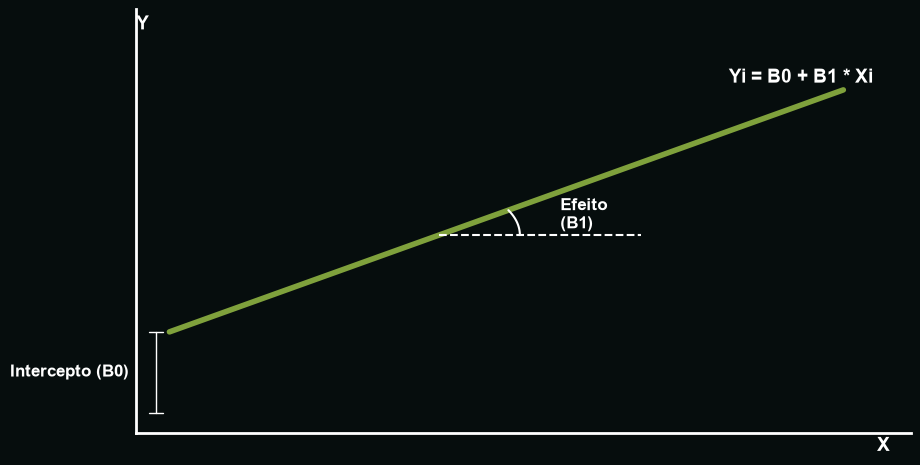

In [172]:
# Gráfico de coeficientes teóricos da Regressão Linear conforme o slide da aula

# Ativa o estilo de fundo escuro para corresponder ao slide do curso
plt.style.use('dark_background')

# Cria a estrutura da imagem com a cor de fundo personalizada do slide
fig, ax = plt.subplots(figsize=(10, 5.5), facecolor='#060d0d')
ax.set_facecolor('#060d0d')

# 1. Configura os dados teóricos da reta matemática (Y = B0 + B1 * X)
x_valores = np.linspace(0, 10, 100)
b0_valor = 2
b1_valor = 0.6
y_valores = b0_valor + b1_valor * x_valores

# 2. Desenha a linha de regressão principal na cor verde do slide
ax.plot(x_valores, y_valores, color='#7fa13c', linewidth=4)

# 3. Formata os eixos cartesianos X e Y como linhas brancas destacadas
ax.spines['left'].set_color('white')
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_color('white')
ax.spines['bottom'].set_linewidth(2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 4. Remove os números dos eixos para focar apenas na explicação conceitual
ax.set_xlim(-0.5, 11)
ax.set_ylim(-0.5, 10)
ax.set_xticks([])
ax.set_yticks([])

# 5. Adiciona os rótulos de identificação dos eixos X e Y
ax.text(-0.3, 9.5, 'Y', color='white', fontsize=14, fontweight='bold', ha='right')
ax.text(10.5, -0.6, 'X', color='white', fontsize=14, fontweight='bold', va='top')

# 6. Adiciona a marcação do Intercepto (B0) com a chave delimitadora na esquerda
ax.plot([-0.2, -0.2], [0, b0_valor], color='white', linewidth=1)
ax.plot([-0.3, -0.1], [0, 0], color='white', linewidth=1)
ax.plot([-0.3, -0.1], [b0_valor, b0_valor], color='white', linewidth=1)
ax.text(-0.6, b0_valor/2, 'Intercepto (B0)', color='white', fontsize=12, fontweight='bold', ha='right', va='center')

# 7. Adiciona a linha pontilhada horizontal de referência para o ângulo do Efeito (B1)
x_ref = 4
y_ref = b0_valor + b1_valor * x_ref
ax.plot([x_ref, x_ref + 3], [y_ref, y_ref], color='white', linestyle='--', linewidth=1.5)

# 8. Cria o arco indicador do ângulo de inclinação da reta (Efeito)
ang_theta = np.linspace(0, np.arctan(b1_valor), 50)
raio_arco = 1.2
ax.plot(x_ref + raio_arco * np.cos(ang_theta), y_ref + raio_arco * np.sin(ang_theta), color='white', linewidth=1.5)
ax.text(x_ref + 1.8, y_ref + 0.5, 'Efeito\n(B1)', color='white', fontsize=12, fontweight='bold', ha='left', va='center')

# 9. Insere o texto da fórmula matemática idêntico ao slide do exercício
# AJUSTADO: Posicionamento corrigido para o texto não ser cortado pela linha verde
ax.text(8.3, b0_valor + b1_valor * 8.3 + 1.2, 'Yi = B0 + B1 * Xi', color='white', fontsize=14, fontweight='bold', ha='left')

# Exibe a figura gerada na tela
plt.show()


Explicabilidade do modelo 

In [173]:
# observando o R²
modelo_0.rsquared

np.float64(0.3772801099429788)

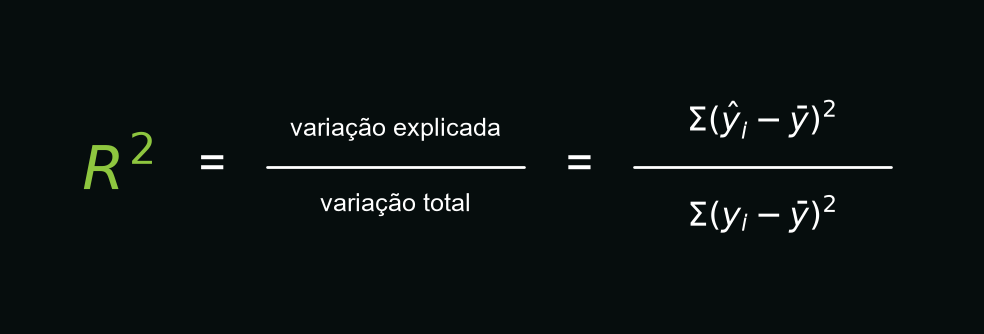

In [174]:
# Infográfico explicativo do R² (Coeficiente de Determinação) conforme o slide da aula

# Ativa o estilo de fundo escuro para corresponder ao slide
plt.style.use('dark_background')

# Cria a estrutura do painel com a cor de fundo customizada do slide
fig, ax = plt.subplots(figsize=(10, 3.5), facecolor='#060d0d')
ax.set_facecolor('#060d0d')

# Remove as bordas e marcações de eixos para focar apenas nos blocos de texto e equações
ax.axis('off')

# 1. Desenha o indicador principal R² em verde-limão e o sinal de igual em branco
ax.text(0.12, 0.5, r'$R^2$', color='#8ec63f', fontsize=44, fontweight='bold', ha='center', va='center')
ax.text(0.22, 0.5, '=', color='white', fontsize=34, ha='center', va='center')

# 2. Desenha a primeira fração em formato de texto descritivo
ax.text(0.42, 0.62, 'variação explicada', color='white', fontsize=18, ha='center', va='center')
ax.plot([0.28, 0.56], [0.5, 0.5], color='white', linewidth=2)  # Linha divisória da fração
ax.text(0.42, 0.38, 'variação total', color='white', fontsize=18, ha='center', va='center')

# 3. Desenha o sinal de igual central
ax.text(0.62, 0.5, '=', color='white', fontsize=34, ha='center', va='center')

# 4. Desenha a segunda fração contendo a fórmula matemática com somatórios utilizando notação LaTeX
# Numerador: Somatório dos desvios explicados (previsão menos a média ao quadrado)
ax.text(0.82, 0.65, r'$\Sigma(\hat{y}_i - \bar{y})^2$', color='white', fontsize=24, ha='center', va='center')
ax.plot([0.68, 0.96], [0.5, 0.5], color='white', linewidth=2)  # Linha divisória da fração
# Denominador: Somatório dos desvios totais (valor real menos a média ao quadrado)
ax.text(0.82, 0.35, r'$\Sigma(y_i - \bar{y})^2$', color='white', fontsize=24, ha='center', va='center')

# Configura as proporções internas da área de exibição
ax.set_xlim(0, 1.05)
ax.set_ylim(0, 1)

# Renderiza e exibe o painel finalizado na célula do notebook
plt.tight_layout()
plt.show()


In [175]:
# Quais são os resíduos
modelo_0.resid

1303   -193023.838744
326    -144522.356193
386     399612.747641
615     -68449.596607
236     166010.592859
            ...      
777     465872.680999
271    -497642.319788
723     461150.204718
560    -540482.733402
768     -37547.820756
Length: 1006, dtype: float64

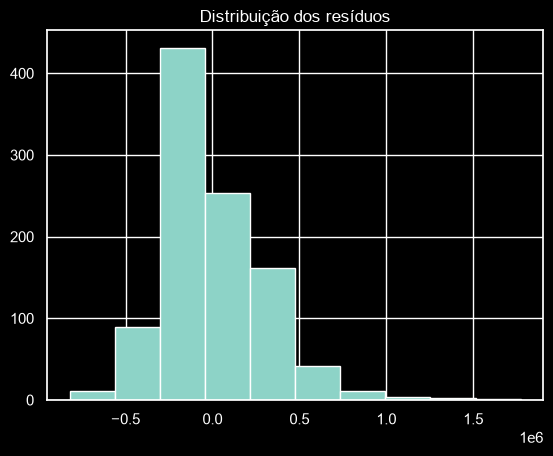

In [176]:
# Como eles estão distribuídos
modelo_0.resid.hist()
plt.title("Distribuição dos resíduos")
plt.show()

In [177]:
# Definindo o y previsto (gerando as previsões do modelo)

# Utiliza o modelo treinado (modelo_0) para fazer previsões de preços 
# com base nos dados de teste (x_test) que ele ainda não tinha visto.
y_predict = modelo_0.predict(x_test)


In [178]:
# importando o r2 score
from sklearn.metrics import r2_score

In [179]:
#printando o R² 
print("R²: ", r2_score(y_test,y_predict))

R²:  0.38530928723202407


Adicionando outras características 

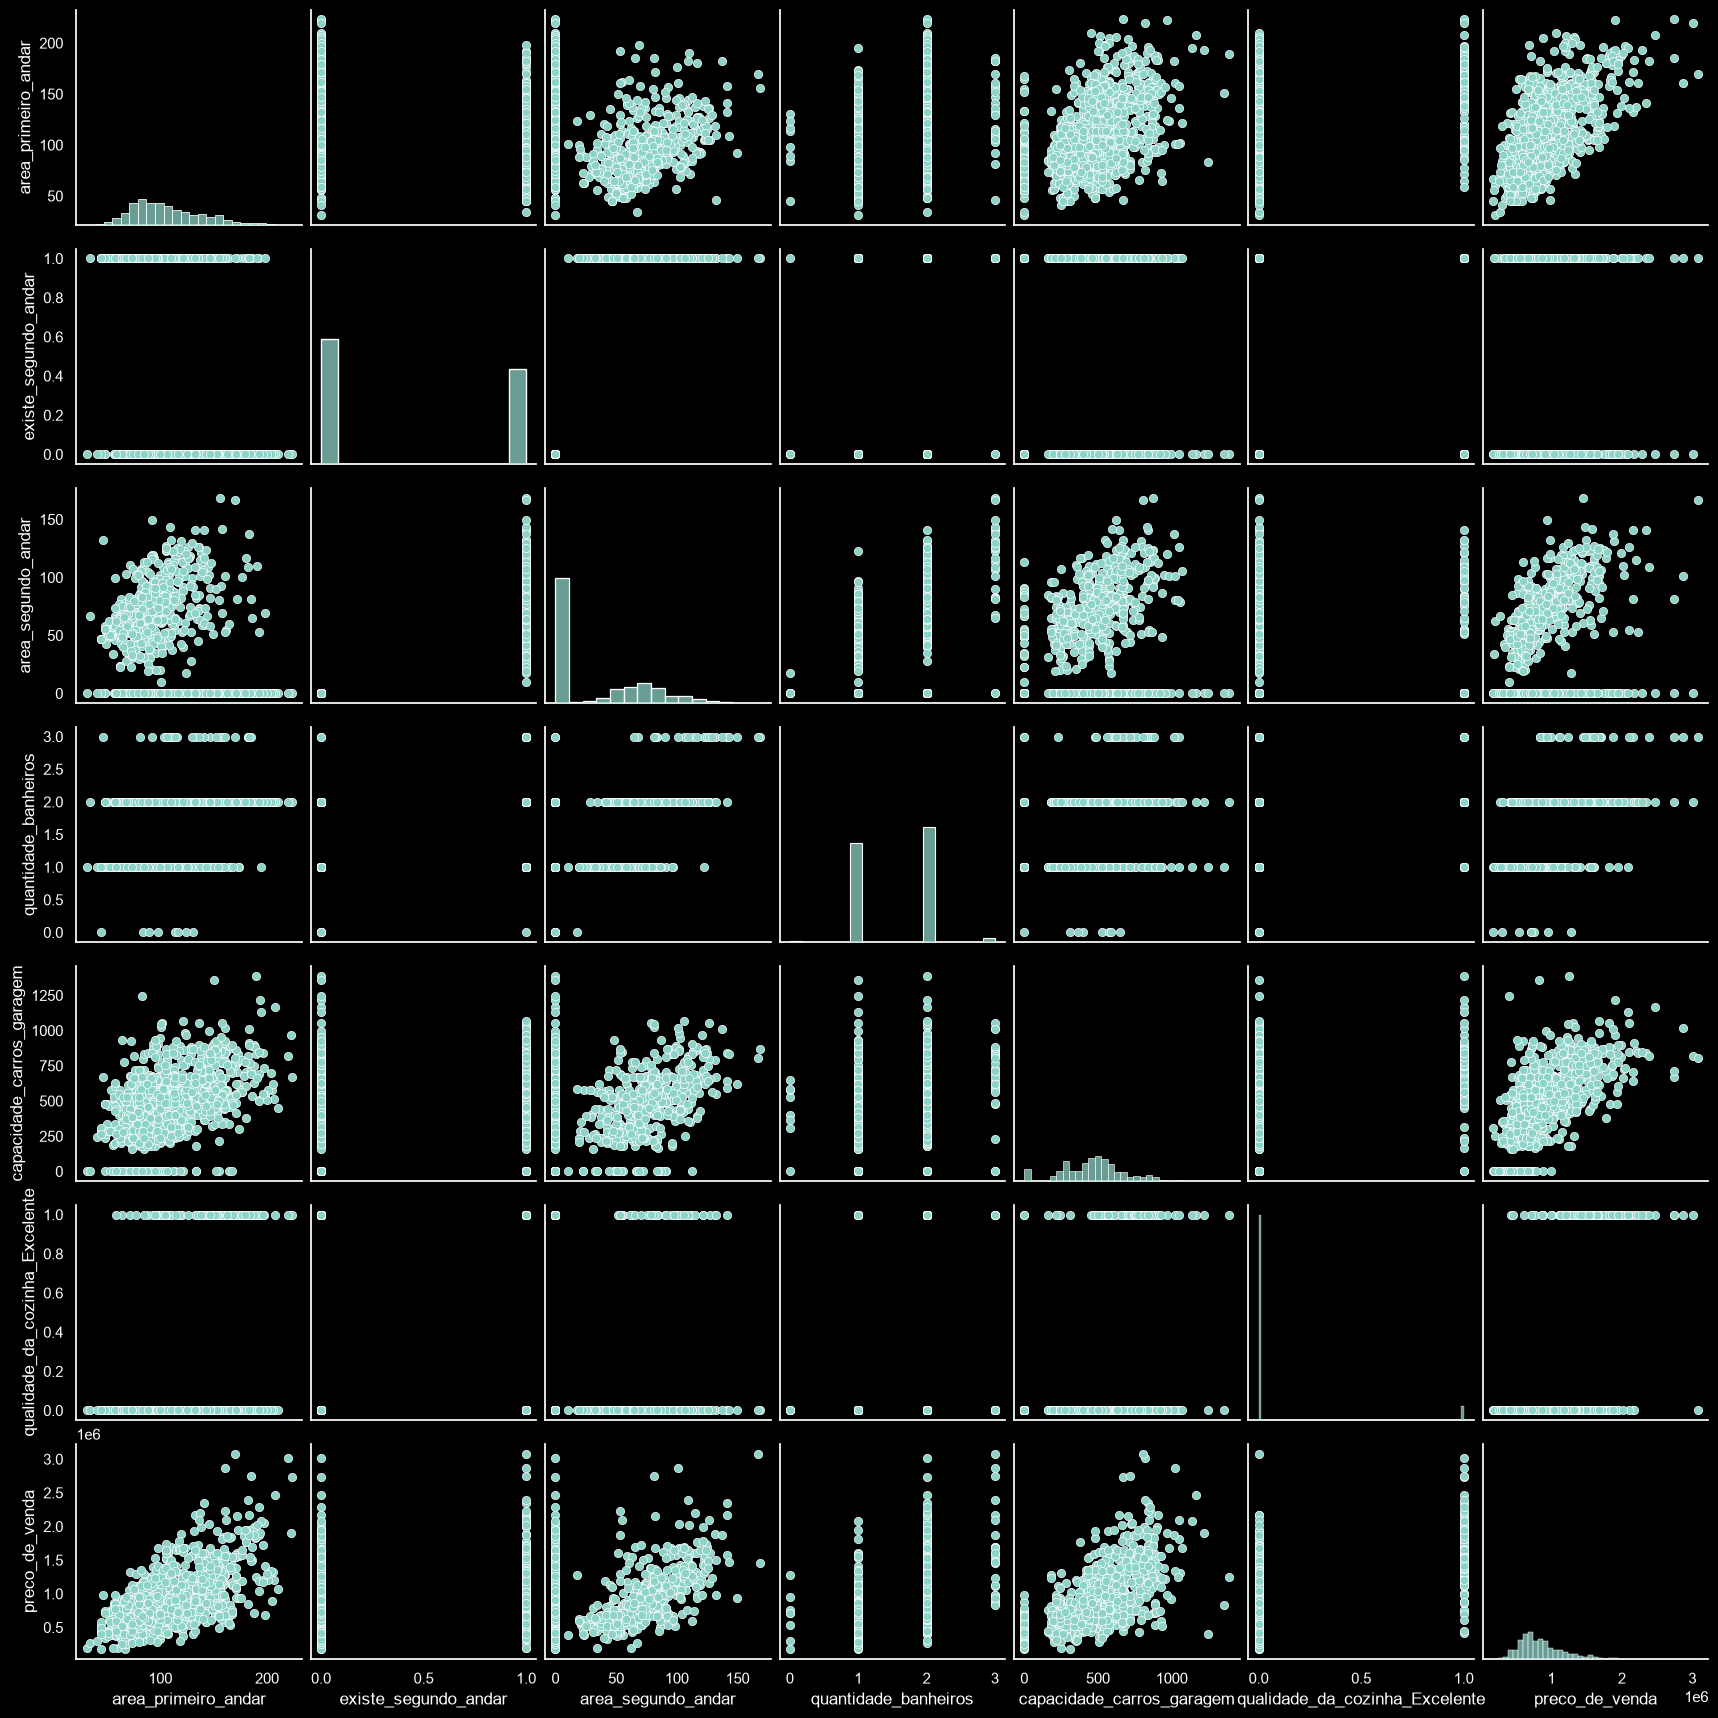

In [180]:
# quais outras características poderiam explicar o preço dos imóveis?
sns.pairplot(dados)

In [181]:
dados.columns

Index(['area_primeiro_andar', 'existe_segundo_andar', 'area_segundo_andar',
       'quantidade_banheiros', 'capacidade_carros_garagem',
       'qualidade_da_cozinha_Excelente', 'preco_de_venda'],
      dtype='str')

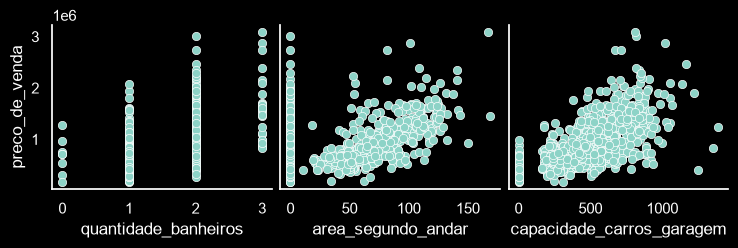

In [182]:
#Vamos olhar apenas com y_vars='preco_de_venda'
sns.pairplot(dados, y_vars = 'preco_de_venda', x_vars = ['quantidade_banheiros','area_segundo_andar','capacidade_carros_garagem'])

In [183]:
# importando a api do statsmodels
import statsmodels.api as sm

In [184]:
# Adicionando a constante ao conjunto de treino

# O Statsmodels precisa que adicionemos manualmente uma coluna de constantes (valores = 1)
# para conseguir calcular o intercepto (B0) da nossa reta de regressão linear.
x_train = sm.add_constant(x_train)


In [185]:
x_train.head()

,const,area_primeiro_andar,existe_segundo_andar,area_segundo_andar,quantidade_banheiros,capacidade_carros_garagem,qualidade_da_cozinha_Excelente
1303,1.0,65.7732,0,0.0000,1,0,0
326,1.0,55.3684,1,55.3684,1,189,0
386,1.0,74.6916,1,107.4853,2,560,0
615,1.0,103.6764,0,0.0000,1,440,0
236,1.0,94.2006,1,67.8170,2,457,0


In [186]:
# Criando o modelo de regressão (sem fómula): saturado
modelo_1 = sm.OLS(y_train,
                  x_train[['const','area_primeiro_andar','existe_segundo_andar',
                          'area_segundo_andar','quantidade_banheiros','capacidade_carros_garagem',
                           'qualidade_da_cozinha_Excelente']]).fit()

In [187]:
# Modelo sem a área do segundo andar
modelo_2 = sm.OLS(y_train,
                  x_train[['const','area_primeiro_andar','existe_segundo_andar',

                          'quantidade_banheiros','capacidade_carros_garagem',

                           'qualidade_da_cozinha_Excelente']]).fit()

In [188]:
# Modelo sem informações sobre garagem
modelo_3 = sm.OLS(y_train,
                  x_train[['const','area_primeiro_andar','existe_segundo_andar',
                          'quantidade_banheiros',
                           'qualidade_da_cozinha_Excelente']]).fit()

In [189]:
# Resumo do modelo 1
print(modelo_1.summary())

                            OLS Regression Results                            
Dep. Variable:         preco_de_venda   R-squared:                       0.741
Model:                            OLS   Adj. R-squared:                  0.740
Method:                 Least Squares   F-statistic:                     477.4
Date:                Fri, 12 Jun 2026   Prob (F-statistic):          2.79e-289
Time:                        22:57:35   Log-Likelihood:                -13640.
No. Observations:                1006   AIC:                         2.729e+04
Df Residuals:                     999   BIC:                         2.733e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

In [190]:
# Resumo do modelo 2
print(modelo_2.summary())

                            OLS Regression Results                            
Dep. Variable:         preco_de_venda   R-squared:                       0.708
Model:                            OLS   Adj. R-squared:                  0.707
Method:                 Least Squares   F-statistic:                     485.3
Date:                Fri, 12 Jun 2026   Prob (F-statistic):          1.93e-264
Time:                        22:57:35   Log-Likelihood:                -13701.
No. Observations:                1006   AIC:                         2.741e+04
Df Residuals:                    1000   BIC:                         2.744e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

In [191]:
# Resumo do modelo 3
print(modelo_3.summary())

                            OLS Regression Results                            
Dep. Variable:         preco_de_venda   R-squared:                       0.651
Model:                            OLS   Adj. R-squared:                  0.650
Method:                 Least Squares   F-statistic:                     467.1
Date:                Fri, 12 Jun 2026   Prob (F-statistic):          4.15e-227
Time:                        22:57:35   Log-Likelihood:                -13790.
No. Observations:                1006   AIC:                         2.759e+04
Df Residuals:                    1001   BIC:                         2.762e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

In [192]:
print("R²")
print("Modelo 0: ", modelo_0.rsquared)
print("Modelo 1: ", modelo_1.rsquared)
print("Modelo 2: ", modelo_2.rsquared)
print("Modelo 3: ", modelo_3.rsquared)

R²
Modelo 0:  0.3772801099429788
Modelo 1:  0.7414024156090393
Modelo 2:  0.7081440416220739
Modelo 3:  0.6511289354898803


In [193]:
#Quantos parametros estão no modelo?
print(len(modelo_0.params))
print(len(modelo_1.params))
print(len(modelo_2.params))
print(len(modelo_3.params))

2
7
6
5


In [194]:
modelo_3.params

const                            -129979.678094
area_primeiro_andar                 6119.653184
existe_segundo_andar              221306.959705
quantidade_banheiros              149036.289458
qualidade_da_cozinha_Excelente    444391.228573
dtype: float64

In [195]:
# Adicionando uma constante em X_test
x_test = sm.add_constant(x_test)

In [196]:
# Prevendo com o modelo_3
predict_3 = modelo_3.predict(x_test[['const', 'area_primeiro_andar',
                   'existe_segundo_andar', 'quantidade_banheiros',
                   'qualidade_da_cozinha_Excelente' ]])

In [197]:
# Qual o R² da previsão?
modelo_3.rsquared

np.float64(0.6511289354898803)

In [198]:
# Qual o R² do treino?
print("R²: ", r2_score(y_test, predict_3))

R²:  0.6432078074497707


In [199]:
modelo_3.params

const                            -129979.678094
area_primeiro_andar                 6119.653184
existe_segundo_andar              221306.959705
quantidade_banheiros              149036.289458
qualidade_da_cozinha_Excelente    444391.228573
dtype: float64

In [200]:
novo_imovel = pd.DataFrame({'const':[1],
                            'area_primeiro_andar':[120],
                            'existe_segundo_andar': [1],
                            'quantidade_banheiros': [2],
                            'qualidade_da_cozinha_Excelente': [0]
                            })

In [201]:
# Qual o preço desse imóvel com o modelo_0?
modelo_0.predict(novo_imovel['area_primeiro_andar'])

0    968146.285305
dtype: float64

In [202]:
# Qual o preço desse imóvel com o modelo_3?
modelo_3.predict(novo_imovel)[0]

np.float64(1123758.2426020517)

Precificando várias casas

In [203]:
# Lendo várias casas
novas_casas = pd.read_csv(r"Dados\Novas_casas.csv", sep=";")

In [204]:
novas_casas.head()

,Casa,area_primeiro_andar,existe_segundo_andar,quantidade_banheiros,qualidade_da_cozinha_Excelente
0,1,150,1,2,1
1,2,180,0,3,1
2,3,120,1,2,1
3,4,200,1,3,1
4,5,160,0,2,1


In [205]:
novas_casas = novas_casas.drop(columns="Casa")

In [206]:
# Adicionando uma constante
novas_casas = sm.add_constant(novas_casas)
novas_casas.head()

,const,area_primeiro_andar,existe_segundo_andar,quantidade_banheiros,qualidade_da_cozinha_Excelente
0,1.0,150,1,2,1
1,1.0,180,0,3,1
2,1.0,120,1,2,1
3,1.0,200,1,3,1
4,1.0,160,0,2,1


In [207]:
# Qual o preço dessas novas casas?
modelo_3.predict(novas_casas)

0    1.751739e+06
1    1.863058e+06
2    1.568149e+06
3    2.206758e+06
4    1.591629e+06
5    1.246151e+06
6    1.357470e+06
7    1.552134e+06
8    9.636478e+05
9    1.639974e+06
dtype: float64

In [211]:
novo_imovel = pd.DataFrame({'const':[1],
                            'area_primeiro_andar':[98],
                            'existe_segundo_andar': [0],
                            'quantidade_banheiros': [1],
                            'qualidade_da_cozinha_Excelente': [1]
                            })



In [214]:
# Fazendo a previsão do preço usando o modelo_3 com os dados do novo imóvel
preco_estimado = modelo_3.predict(novo_imovel)

# Exibindo o resultado final bruto na tela
preco_estimado


0    1.063174e+06
dtype: float64

In [215]:
# Acessa o índice [0] do resultado e formata como valor monetário legível
print(f"O preço estimado para esta casa é de: ${modelo_3.predict(novo_imovel)[0]:,.2f}")


O preço estimado para esta casa é de: $1,063,173.85
